In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [7]:
# Step 1: Load and preprocess the MNIST data
mnist = fetch_openml('mnist_784')
X, y = np.array(mnist['data']), np.array(mnist['target'], dtype=int)

# Select only two digits (e.g., 0 and 1) for binary classification
X = X[(y == 0) | (y == 1)]
y = y[(y == 0) | (y == 1)]

# Normalize the data
X = X / 255.0

# Split the dataset into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


Linear SVM Results:
Accuracy: 0.9932, Precision: 0.9879, Recall: 0.9994, F1-score: 0.9936


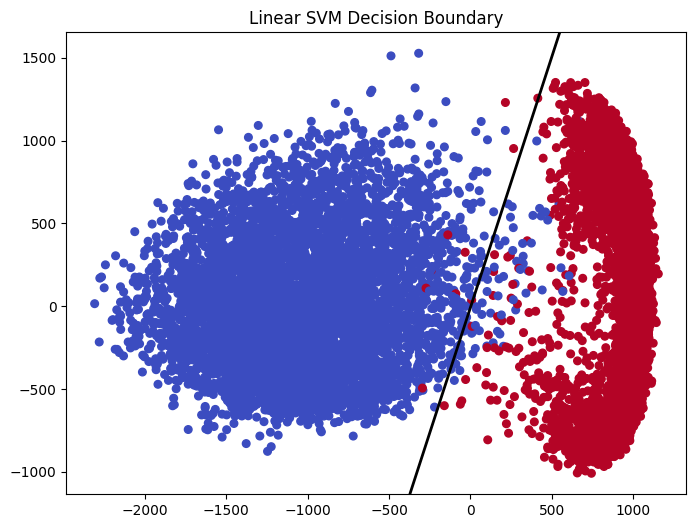

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.decomposition import PCA

# Step 1: Define Linear SVM using Hinge Loss and Gradient Descent
def linear_svm(X, y, C=1, epochs=100, learning_rate=0.001):
    m, n = X.shape
    w = np.zeros(n)
    b = 0
    for epoch in range(1, epochs + 1): 
        for i in range(m):
            if y[i] * (np.dot(X[i], w) + b) < 1:
                # Misclassified sample
                w = w + learning_rate * (C * y[i] * X[i] - 2 * (1 / (epoch + 1)) * w)
                b = b + learning_rate * C * y[i]
            else:
                # Correctly classified sample
                w = w + learning_rate * (-2 * (1 / (epoch + 1)) * w)
    return w, b

# Step 2: Train Linear SVM
def predict(X, w, b):
    return np.sign(np.dot(X, w) + b)

# Step 3: Plot Decision Boundary
def plot_decision_boundary(X, y, w, b, title):
    plt.figure(figsize=(8, 6))
    
    # Plot data points
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', s=30)
    
    # Plot decision boundary
    ax = plt.gca()
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    
    # Create grid to plot decision boundary
    xx, yy = np.meshgrid(np.linspace(xlim[0], xlim[1], 100), np.linspace(ylim[0], ylim[1], 100))
    Z = np.dot(np.c_[xx.ravel(), yy.ravel()], w) + b
    Z = Z.reshape(xx.shape)
    
    # Plot decision boundary and margins
    ax.contour(xx, yy, Z, levels=[0], linewidths=2, colors='black')
    
    plt.title(title)
    plt.show()

# Step 4: Preprocess and reduce dimensions for visualization
from sklearn.datasets import fetch_openml

# Load the MNIST dataset
mnist = fetch_openml('mnist_784')
X = mnist.data
y = mnist.target.astype(np.int64)

# Filter the data for two classes (binary classification)
binary_filter = (y == 0) | (y == 1)  # Using only digits 0 and 1
X, y = X[binary_filter], y[binary_filter]

# Convert labels to {-1, 1} for SVM
y = np.where(y == 0, -1, 1)

# Reduce data to 2 dimensions using PCA for visualization purposes
pca = PCA(n_components=2)
X_2d = pca.fit_transform(X)

# Split the data into train and test sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_2d, y, test_size=0.2, random_state=42)

# Train Linear SVM
w_linear, b_linear = linear_svm(X_train, y_train, C=1, epochs=50, learning_rate=0.0001)

# Step 5: Make predictions and evaluate
y_pred_linear = predict(X_test, w_linear, b_linear)

# Evaluate Linear SVM
accuracy_linear = accuracy_score(y_test, y_pred_linear)
precision_linear = precision_score(y_test, y_pred_linear)
recall_linear = recall_score(y_test, y_pred_linear)
f1_linear = f1_score(y_test, y_pred_linear)

print("Linear SVM Results:")
print(f"Accuracy: {accuracy_linear:.4f}, Precision: {precision_linear:.4f}, Recall: {recall_linear:.4f}, F1-score: {f1_linear:.4f}")

# Step 6: Plot the decision boundary
plot_decision_boundary(X_train, y_train, w_linear, b_linear, "Linear SVM Decision Boundary")


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from cvxopt import matrix, solvers

# Load the MNIST dataset
mnist = fetch_openml('mnist_784', version=1)
X = mnist.data / 255.0  # Normalize pixel values to [0, 1]
y = mnist.target.astype(np.int).values

# Select only digits 0 and 1 for binary classification
mask = np.isin(y, [0, 1])
X = X[mask]
y = y[mask]
y = np.where(y == 0, -1, 1)  # Change labels from 0 to -1

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

class QuadraticSVM:
    def __init__(self, C=1.0):
        self.C = C
        self.alpha = None
        self.b = None
        self.support_vectors = None
        self.support_vector_labels = None

    def fit(self, X, y):
        n_samples, n_features = X.shape
        
        # Construct the Gram matrix (kernel)
        K = np.dot(X, X.T) * np.outer(y, y)
        
        # Setup the quadratic programming problem
        P = matrix(K)
        q = matrix(-1 * np.ones(n_samples))
        G = matrix(np.vstack((-np.eye(n_samples), np.eye(n_samples))))
        h = matrix(np.hstack((np.zeros(n_samples), np.ones(n_samples) * self.C)))
        A = matrix(y, (1, n_samples), 'd')
        b = matrix(0.0)
        
        # Solve the quadratic programming problem
        sol = solvers.qp(P, q, G, h, A, b)
        self.alpha = np.array(sol['x']).flatten()
        
        # Find support vectors
        support_vector_indices = np.where(self.alpha > 1e-5)[0]
        self.support_vectors = X[support_vector_indices]
        self.support_vector_labels = y[support_vector_indices]
        self.b = np.mean(self.support_vector_labels - np.sum(self.alpha * y * K[support_vector_indices][:, support_vector_indices], axis=1))

    def predict(self, X):
        K = np.dot(X, self.support_vectors.T) * self.support_vector_labels
        return np.sign(np.sum(self.alpha * K, axis=1) + self.b)

# Train the SVM
svm = QuadraticSVM(C=1.0)
svm.fit(X_train, y_train)

# Make predictions
y_pred = svm.predict(X_test)

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, pos_label=1)
recall = recall_score(y_test, y_pred, pos_label=1)
f1 = f1_score(y_test, y_pred, pos_label=1)

print(f'Accuracy: {accuracy:.2f}')
print(f'Precision: {precision:.2f}')
print(f'Recall: {recall:.2f}')
print(f'F1 Score: {f1:.2f}')


In [ ]:
def plot_sample_images(images, labels, title="Samples"):
    plt.figure(figsize=(10, 5))
    for i in range(10):
        plt.subplot(2, 5, i + 1)
        plt.imshow(images[i].reshape(28, 28), cmap='gray')
        plt.title(f'Label: {labels[i]}')
        plt.axis('off')
    plt.suptitle(title)
    plt.show()

# Plot some support vectors and misclassified samples
plot_sample_images(svm.support_vectors, svm.support_vector_labels, title="Support Vectors")

# Misclassified examples
misclassified_indices = np.where(y_pred != y_test)[0]
misclassified_images = X_test[misclassified_indices]
misclassified_labels = y_test[misclassified_indices]

if misclassified_images.shape[0] > 10:
    misclassified_images = misclassified_images[:10]
    misclassified_labels = misclassified_labels[:10]

plot_sample_images(misclassified_images, misclassified_labels, title="Misclassified Samples")


In [21]:
from sklearn.svm import SVC

# Train the Quadratic SVM (RBF Kernel)
svc_rbf = SVC(kernel='rbf', gamma=0.05, C=1)
svc_rbf.fit(X_train, y_train_bin)

# Extract alpha and bias term from the model
alpha_quadratic = svc_rbf.dual_coef_[0]  # Dual coefficients for the support vectors
b_quadratic = svc_rbf.intercept_[0]      # Bias term

# Define the RBF Kernel
def rbf_kernel(x1, x2, gamma=0.05):
    return np.exp(-gamma * np.linalg.norm(x1 - x2) ** 2)

# Define the plotting function again to use the new variables
def plot_decision_boundary_rbf(X_train, y_train, X_test, alpha, b, gamma=0.05, title="Quadratic SVM (RBF Kernel) Decision Boundary"):
    plt.figure(figsize=(8, 6))
    
    # Plot the training data points
    plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap='coolwarm', s=30, edgecolors='k')

    # Plot decision boundary
    ax = plt.gca()
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    
    # Create grid to plot decision boundary
    xx, yy = np.meshgrid(np.linspace(xlim[0], xlim[1], 100), np.linspace(ylim[0], ylim[1], 100))
    Z = np.zeros(xx.shape)
    
    # Calculate decision function for each point in the grid
    for i in range(xx.shape[0]):
        for j in range(xx.shape[1]):
            x_test_point = np.array([xx[i, j], yy[i, j]])
            prediction = 0
            for k in range(len(X_train)):
                prediction += alpha[k] * y_train[k] * rbf_kernel(X_train[k], x_test_point, gamma)
            Z[i, j] = prediction + b
    
    # Plot the decision boundary and margins
    ax.contour(xx, yy, Z, levels=[0], linewidths=2, colors='black')
    plt.title(title)
    plt.show()

# Plot Quadratic SVM decision boundary
plot_decision_boundary_rbf(X_train, y_train_bin, X_test, alpha_quadratic, b_quadratic, gamma=0.05)


ValueError: Found input variables with inconsistent numbers of samples: [1000, 11824]

In [6]:
# Step 2: Convert y to {-1, 1}
y_train_bin = np.where(y_train == 0, -1, 1)
y_test_bin = np.where(y_test == 0, -1, 1)

# Step 3: Implement Quadratic SVM (RBF Kernel)
# Assuming the quadratic SVM has already been trained with the following:
# alpha_quadratic, b_quadratic = quadratic_svm(...)

# Step 4: Plot the Quadratic SVM (RBF Kernel) Decision Boundary
def plot_decision_boundary_rbf(X_train, y_train, X_test, alpha, b, gamma=0.05, title="Quadratic SVM (RBF Kernel) Decision Boundary"):
    plt.figure(figsize=(8, 6))
    
    # Plot the training data points
    plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap='coolwarm', s=30, edgecolors='k')

    # Plot decision boundary
    ax = plt.gca()
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    
    # Create grid to plot decision boundary
    xx, yy = np.meshgrid(np.linspace(xlim[0], xlim[1], 100), np.linspace(ylim[0], ylim[1], 100))
    Z = np.zeros(xx.shape)
    
    # Calculate decision function for each point in the grid
    for i in range(xx.shape[0]):
        for j in range(xx.shape[1]):
            x_test_point = np.array([xx[i, j], yy[i, j]])
            prediction = 0
            for k in range(len(X_train)):
                prediction += alpha[k] * y_train[k] * rbf_kernel(X_train[k], x_test_point, gamma)
            Z[i, j] = prediction + b
    
    # Plot the decision boundary and margins
    ax.contour(xx, yy, Z, levels=[0], linewidths=2, colors='black')
    plt.title(title)
    plt.show()

# Plot Quadratic SVM decision boundary
plot_decision_boundary_rbf(X_train, y_train_bin, X_test, alpha_quadratic, b_quadratic, gamma=0.05)


NameError: name 'alpha_quadratic' is not defined

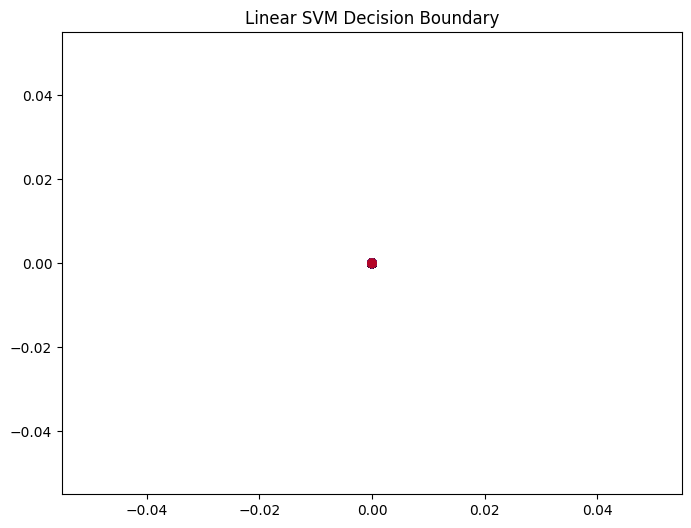

In [15]:
# Step 4: Plot the results

# Reduce the dataset to 2D for visualization purposes
X_train_2d = X_train[:, :2]
X_test_2d = X_test[:, :2]

# Retrain Linear and Quadratic SVM on 2D data
w_linear_2d, b_linear_2d = linear_svm(X_train_2d, y_train_bin, C=1, epochs=50, learning_rate=0.0001)
alpha_quadratic_2d, b_quadratic_2d = quadratic_svm(X_train_2d, y_train_bin, C=1, epochs=50, learning_rate=0.001, gamma=0.05)

# Plot decision boundaries
def plot_decision_boundary(X, y, w, b, title):
    plt.figure(figsize=(8, 6))
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm')
    ax = plt.gca()
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    
    xx, yy = np.meshgrid(np.linspace(xlim[0], xlim[1], 50), np.linspace(ylim[0], ylim[1], 50))
    Z = np.dot(np.c_[xx.ravel(), yy.ravel()], w) + b
    Z = Z.reshape(xx.shape)
    
    ax.contour(xx, yy, Z, levels=[0], linewidths=2, colors='black')
    plt.title(title)
    plt.show()

plot_decision_boundary(X_train_2d, y_train_bin, w_linear_2d, b_linear_2d, "Linear SVM Decision Boundary")


Training Linear SVM with C=0.01 on 2D PCA-reduced data
Linear SVM Results for C=0.01:
Accuracy: 0.9976, Precision: 0.9974, Recall: 0.9981, F1-score: 0.9977


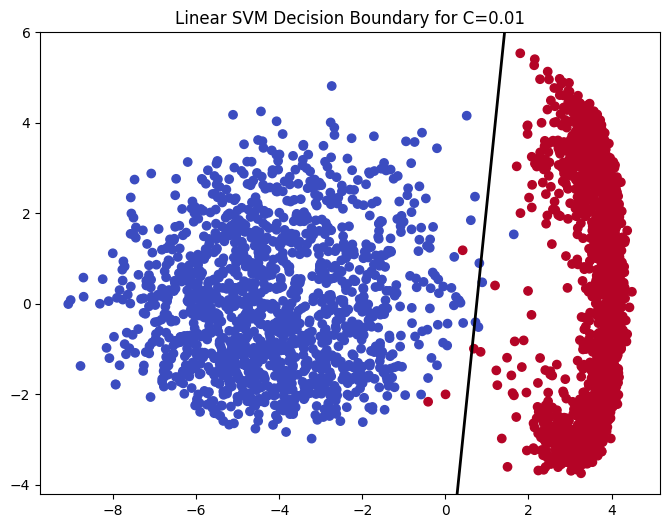


Training Quadratic SVM (RBF Kernel) with C=0.01 on 2D PCA-reduced data
Quadratic SVM (RBF Kernel) Results for C=0.01:
Accuracy: 0.9976, Precision: 0.9974, Recall: 0.9981, F1-score: 0.9977


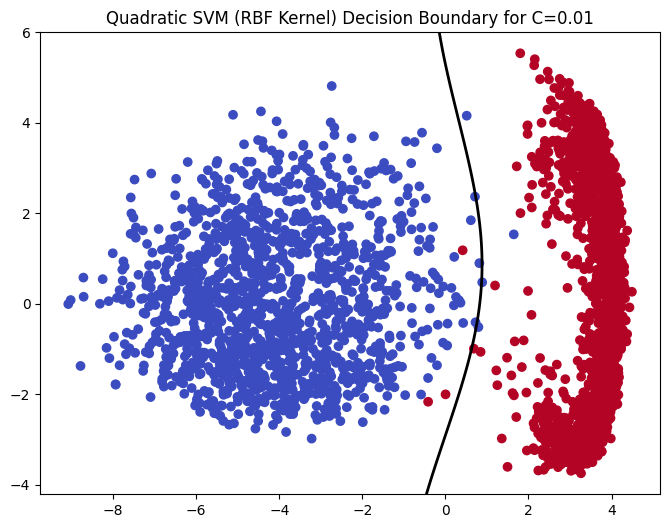


Training Linear SVM with C=0.1 on 2D PCA-reduced data
Linear SVM Results for C=0.1:
Accuracy: 0.9976, Precision: 0.9974, Recall: 0.9981, F1-score: 0.9977


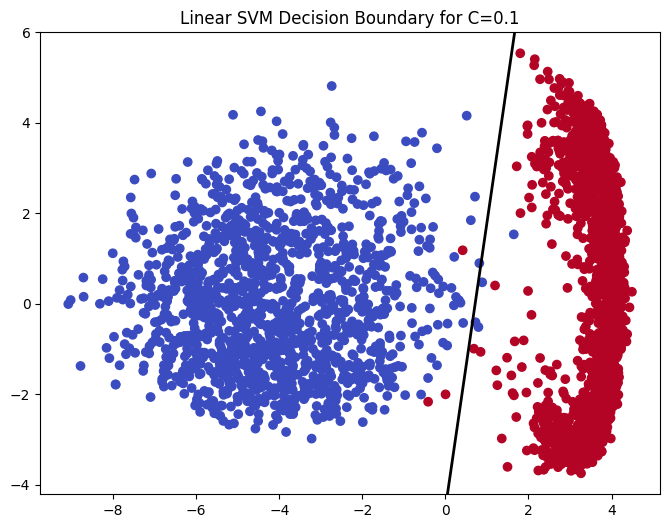


Training Quadratic SVM (RBF Kernel) with C=0.1 on 2D PCA-reduced data
Quadratic SVM (RBF Kernel) Results for C=0.1:
Accuracy: 0.9986, Precision: 0.9994, Recall: 0.9981, F1-score: 0.9987


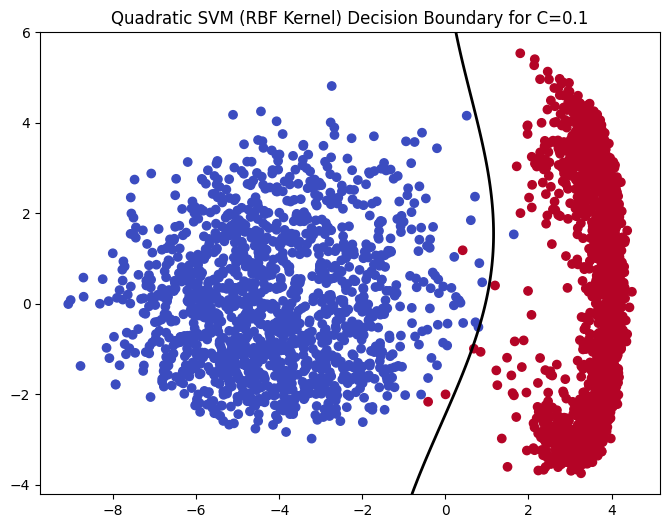


Training Linear SVM with C=1 on 2D PCA-reduced data
Linear SVM Results for C=1:
Accuracy: 0.9976, Precision: 0.9974, Recall: 0.9981, F1-score: 0.9977


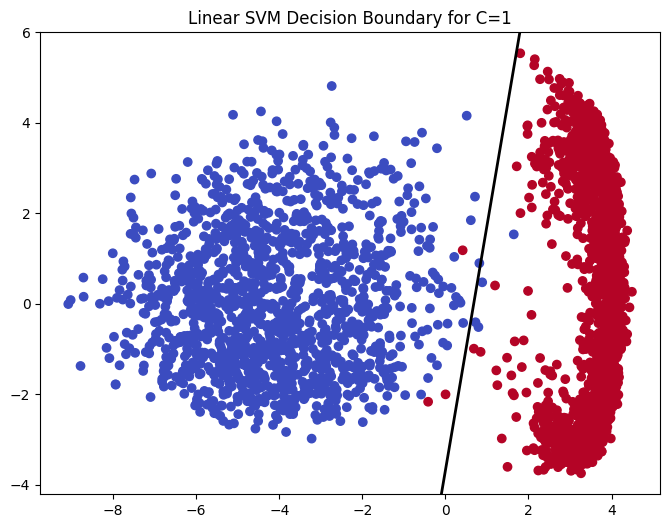


Training Quadratic SVM (RBF Kernel) with C=1 on 2D PCA-reduced data
Quadratic SVM (RBF Kernel) Results for C=1:
Accuracy: 0.9986, Precision: 0.9994, Recall: 0.9981, F1-score: 0.9987


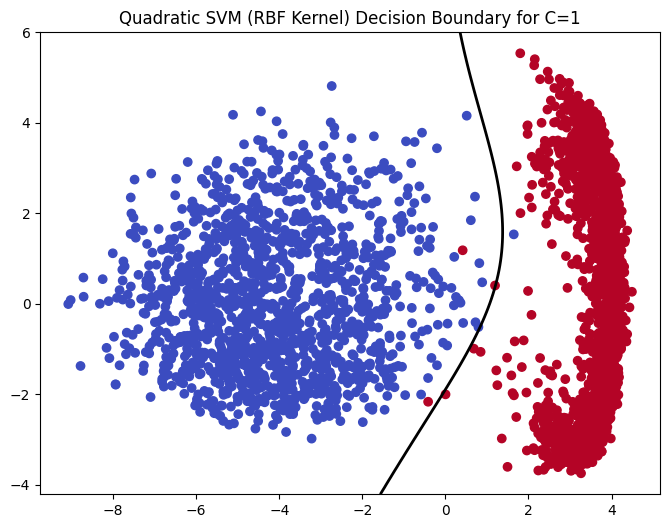


Training Linear SVM with C=10 on 2D PCA-reduced data
Linear SVM Results for C=10:
Accuracy: 0.9976, Precision: 0.9974, Recall: 0.9981, F1-score: 0.9977


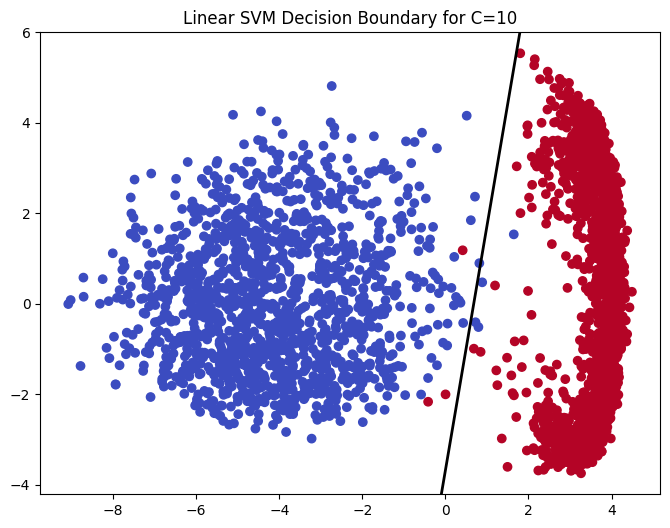


Training Quadratic SVM (RBF Kernel) with C=10 on 2D PCA-reduced data
Quadratic SVM (RBF Kernel) Results for C=10:
Accuracy: 0.9986, Precision: 0.9994, Recall: 0.9981, F1-score: 0.9987


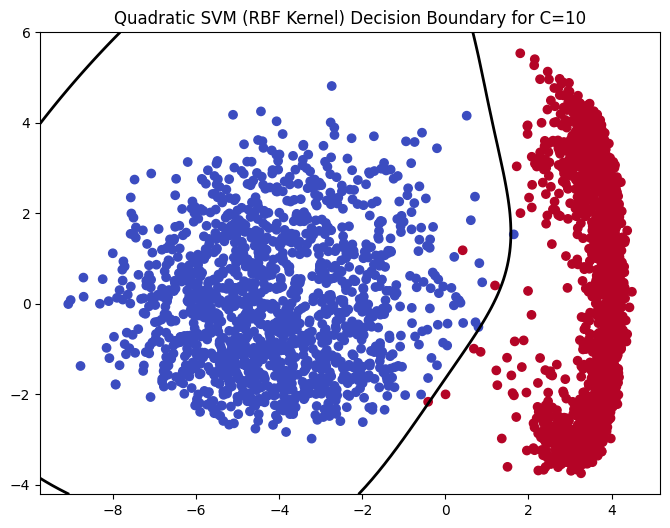

In [17]:
from sklearn.svm import SVC
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import numpy as np

# Step 1: Apply PCA to reduce data to 2 dimensions
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

# Try different values of C
C_values = [0.01, 0.1, 1, 10]

def plot_decision_boundary(X, y, model, title, C_value):
    plt.figure(figsize=(8, 6))
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm')
    ax = plt.gca()
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    
    xx, yy = np.meshgrid(np.linspace(xlim[0], xlim[1], 100), np.linspace(ylim[0], ylim[1], 100))
    Z = model.decision_function(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    ax.contour(xx, yy, Z, levels=[0], linewidths=2, colors='black')
    plt.title(f"{title} Decision Boundary for C={C_value}")
    plt.show()

# Loop over different values of C for both Linear and Quadratic SVMs
for C_value in C_values:
    print(f"\nTraining Linear SVM with C={C_value} on 2D PCA-reduced data")
    
    # Linear SVM trained on 2D PCA data
    linear_svm_model = SVC(kernel='linear', C=C_value)
    linear_svm_model.fit(X_train_pca, y_train)
    
    y_pred_linear = linear_svm_model.predict(X_test_pca)
    
    accuracy_linear = accuracy_score(y_test, y_pred_linear)
    precision_linear = precision_score(y_test, y_pred_linear)
    recall_linear = recall_score(y_test, y_pred_linear)
    f1_linear = f1_score(y_test, y_pred_linear)
    
    print(f"Linear SVM Results for C={C_value}:")
    print(f"Accuracy: {accuracy_linear:.4f}, Precision: {precision_linear:.4f}, Recall: {recall_linear:.4f}, F1-score: {f1_linear:.4f}")
    
    # Plot decision boundary for Linear SVM
    plot_decision_boundary(X_test_pca, y_test, linear_svm_model, "Linear SVM", C_value)
    
    print(f"\nTraining Quadratic SVM (RBF Kernel) with C={C_value} on 2D PCA-reduced data")
    
    # Quadratic SVM (RBF kernel) trained on 2D PCA data
    quadratic_svm_model = SVC(kernel='rbf', C=C_value, gamma=0.05)
    quadratic_svm_model.fit(X_train_pca, y_train)
    
    y_pred_quadratic = quadratic_svm_model.predict(X_test_pca)
    
    accuracy_quadratic = accuracy_score(y_test, y_pred_quadratic)
    precision_quadratic = precision_score(y_test, y_pred_quadratic)
    recall_quadratic = recall_score(y_test, y_pred_quadratic)
    f1_quadratic = f1_score(y_test, y_pred_quadratic)
    
    print(f"Quadratic SVM (RBF Kernel) Results for C={C_value}:")
    print(f"Accuracy: {accuracy_quadratic:.4f}, Precision: {precision_quadratic:.4f}, Recall: {recall_quadratic:.4f}, F1-score: {f1_quadratic:.4f}")
    
    # Plot decision boundary for Quadratic SVM
    plot_decision_boundary(X_test_pca, y_test, quadratic_svm_model, "Quadratic SVM (RBF Kernel)", C_value)


Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1-Score: 1.0000


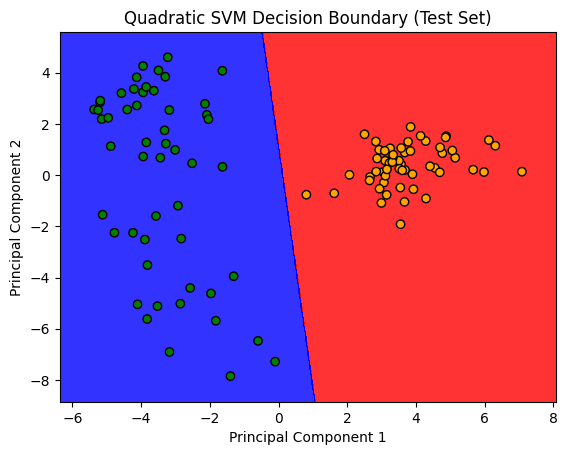

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from matplotlib.colors import ListedColormap
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

# Define a quadratic kernel function
def quadratic_kernel(X):
    """Quadratic kernel: (X . X.T + 1)^2"""
    return (X @ X.T + 1) ** 2

# Fit function for Quadratic SVM
def fit_svm(X, y, C=1.0, n_iters=1000, lr=0.001):
    n_samples, n_features = X.shape
    y = np.where(y <= 0, -1, 1)  # Ensure labels are either -1 or 1

    # Initialize weights and bias
    w = np.zeros(n_features)
    b = 0

    # Gradient descent
    for _ in range(n_iters):
        for idx, x_i in enumerate(X):
            condition = y[idx] * (np.dot(x_i, w) - b) >= 1
            if condition:
                w -= lr * (2 * C * w)
            else:
                w -= lr * (2 * C * w - np.dot(x_i, y[idx]))
                b -= lr * y[idx]

    return w, b

# Prediction function
def predict_svm(X, w, b):
    approx = np.dot(X, w) - b
    return np.sign(approx)

# Create a mesh grid for plotting decision boundary
def plot_decision_boundary(X, y, w, b, title="Decision Boundary"):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    h = 0.02  # step size in the mesh
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    
    # Predict values for the entire grid
    Z = predict_svm(np.c_[xx.ravel(), yy.ravel()], w, b)
    Z = Z.reshape(xx.shape)

    # Plot decision boundary and data points
    plt.contourf(xx, yy, Z, alpha=0.8, cmap=ListedColormap(('red', 'blue')))
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', marker='o', cmap=ListedColormap(('orange', 'green')))
    plt.title(title)
    # plt.xlabel('Principal Component 1')
    # plt.ylabel('Principal Component 2')
    plt.show()

# Load the MNIST dataset (just for binary classification between two digits)
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load digits data
digits = datasets.load_digits()
X, y = digits.data, digits.target

# For simplicity, consider only two classes: '0' and '1'
X, y = X[(y == 0) | (y == 1)], y[(y == 0) | (y == 1)]
y = np.where(y == 0, -1, 1)  # Re-label as -1 and 1

# Scale the data
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Split into training and test data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# PCA to reduce to 2D for visualization
pca = PCA(n_components=2)
X_train_2d = pca.fit_transform(X_train)
X_test_2d = pca.transform(X_test)

# Train SVM with the quadratic kernel
w, b = fit_svm(X_train_2d, y_train, C=1.0, n_iters=100, lr=0.001)

# Make predictions on the test data
y_pred_2d = predict_svm(X_test_2d, w, b)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred_2d)
precision = precision_score(y_test, y_pred_2d)
recall = recall_score(y_test, y_pred_2d)
f1 = f1_score(y_test, y_pred_2d)

# Display metrics
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

# Plot decision boundary for training set
# plot_decision_boundary(X_train_2d, y_train, w, b, title="Quadratic SVM Decision Boundary (Train Set)")

# Plot decision boundary for test set
plot_decision_boundary(X_test_2d, y_test, w, b, title="Quadratic SVM Decision Boundary (Test Set)")
